In [1]:
print("AI Project Started")

AI Project Started


In [1]:
print("Notebook Working")

Notebook Working


In [5]:
import pandas as pd

captions = pd.read_csv("../data/captions.txt")

captions.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [9]:
import os

print(os.listdir("../data"))

['.ipynb_checkpoints', 'captions.txt', 'Flickr8k_Dataset', 'Images']


In [10]:
print(os.listdir("../data/Flickr8k_Dataset")[:5])

[]


In [14]:
import os

print(os.listdir("../data"))

['.ipynb_checkpoints', 'captions.txt', 'Flickr8k_Dataset', 'Images']


Caption: A child in a pink dress is climbing up a set of stairs in an entry way .


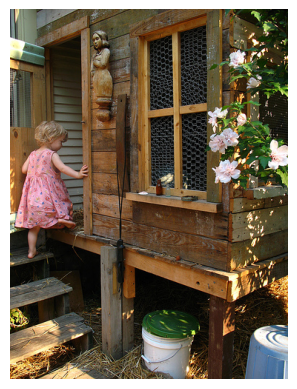

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

# Get first image and caption
img_name = captions.iloc[0]['image']
caption = captions.iloc[0]['caption']

# Correct image path
img_path = f"../data/Images/{img_name}"

# Open image
img = Image.open(img_path)

# Display image
plt.imshow(img)
plt.axis('off')

# Print caption
print("Caption:", caption)

In [19]:
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.models import Model

# Load pretrained model
model = InceptionV3(weights='imagenet')

# Remove last classification layer
model = Model(model.input, model.layers[-2].output)

print("InceptionV3 Loaded Successfully 🚀")

InceptionV3 Loaded Successfully 🚀


In [20]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import preprocess_input
import numpy as np

# Get image path
img_name = captions.iloc[0]['image']
img_path = f"../data/Images/{img_name}"

# Load image
img = load_img(img_path, target_size=(299, 299))

# Convert image to array
img = img_to_array(img)

# Reshape for model
img = np.expand_dims(img, axis=0)

# Preprocess image
img = preprocess_input(img)

# Extract features
features = model.predict(img)

print("Feature Shape:", features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Feature Shape: (1, 2048)


In [21]:
from tqdm import tqdm
import pickle
import os

# Dictionary to store features
features_dict = {}

# Path to images folder
images_path = "../data/Images"

# Get all image names
image_names = os.listdir(images_path)

print("Total Images:", len(image_names))

# Loop through images
for img_name in tqdm(image_names):

    # Full image path
    img_path = os.path.join(images_path, img_name)

    # Load image
    img = load_img(img_path, target_size=(299, 299))
    img = img_to_array(img)

    # Reshape
    img = np.expand_dims(img, axis=0)

    # Preprocess
    img = preprocess_input(img)

    # Extract features
    feature = model.predict(img, verbose=0)

    # Store features
    features_dict[img_name] = feature

# Save features
pickle.dump(features_dict, open("../models/features.pkl", "wb"))

print("Feature Extraction Completed 🚀")

Total Images: 8091


100%|███████████████████████████████████████████████| 8091/8091 [30:04<00:00,  4.48it/s]


Feature Extraction Completed 🚀


In [23]:
def clean_caption(caption):
    
    # Convert to lowercase
    caption = caption.lower()
    
    # Remove special characters
    caption = ''.join(char for char in caption if char.isalpha() or char == ' ')
    
    # Remove extra spaces
    caption = ' '.join(caption.split())
    
    # Add start and end tokens
    caption = 'startseq ' + caption + ' endseq'
    
    return caption

# Apply cleaning
captions['caption'] = captions['caption'].apply(clean_caption)

# Show sample
captions.head()

,image,caption
0,1000268201_693b08cb0e.jpg,startseq a child in a pink dress is climbing u...
1,1000268201_693b08cb0e.jpg,startseq a girl going into a wooden building e...
2,1000268201_693b08cb0e.jpg,startseq a little girl climbing into a wooden ...
3,1000268201_693b08cb0e.jpg,startseq a little girl climbing the stairs to ...
4,1000268201_693b08cb0e.jpg,startseq a little girl in a pink dress going i...


In [24]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Create tokenizer
tokenizer = Tokenizer()

# Fit tokenizer on captions
tokenizer.fit_on_texts(captions['caption'])

# Vocabulary size
vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 8781


In [25]:
# Find maximum caption length
max_length = max(captions['caption'].apply(lambda x: len(x.split())))

print("Maximum Caption Length:", max_length)

Maximum Caption Length: 37


In [27]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

X1, X2, y = [], [], []

# Loop through captions
for i in range(len(captions)):

    caption = captions.iloc[i]['caption']
    img_name = captions.iloc[i]['image']

    # Skip if feature missing
    if img_name not in features_dict:
        continue

    # Convert caption to sequence
    seq = tokenizer.texts_to_sequences([caption])[0]

    # Generate sequences
    for j in range(1, len(seq)):

        in_seq = seq[:j]
        out_seq = seq[j]

        # Pad sequence
        in_seq = pad_sequences([in_seq], maxlen=max_length)[0]

        # Store
        X1.append(features_dict[img_name][0])
        X2.append(in_seq)
        y.append(out_seq)

# Convert to numpy arrays
X1 = np.array(X1)
X2 = np.array(X2)
y = np.array(y)

print("Training Data Prepared 🚀")
print("X1 Shape:", X1.shape)
print("X2 Shape:", X2.shape)
print("y Shape:", y.shape)

Training Data Prepared 🚀
X1 Shape: (476793, 2048)
X2 Shape: (476793, 37)
y Shape: (476793,)
